# Jupyter notebook: Xử lý ảnh biển số và nhận diện OCR

Notebook này hướng dẫn các bước xử lý ảnh biển số xe và nhận diện ký tự bằng OCR (pytesseract).

In [1]:
# 1. Import Required Libraries
import cv2
import matplotlib.pyplot as plt

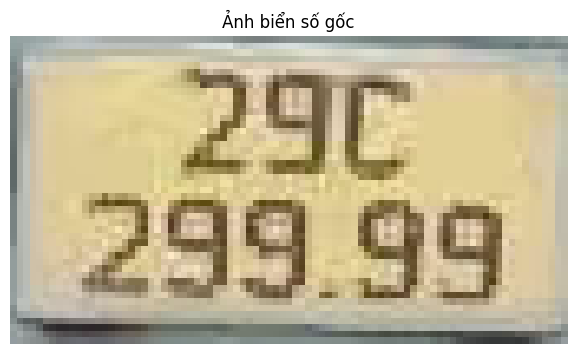

In [79]:
# 2. Load and Display License Plate Image
# Đường dẫn ảnh biển số (thay bằng ảnh của bạn)
# image_path = r'D:\TrucNV\vehicle_detection_tracker\screenshots\20260121\154128_2\license_frame_20260121_154128_806.png'
image_path = r"D:\TrucNV\vehicle_detection_tracker\screenshots\20260121\140043_2071\license_frame_20260121_140043_392.png"
img = cv2.imread(image_path)
# img = img[3:-3,3:-3,:]
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,4))
plt.imshow(img_rgb)
plt.title('Ảnh biển số gốc')
plt.axis('off')
plt.show()

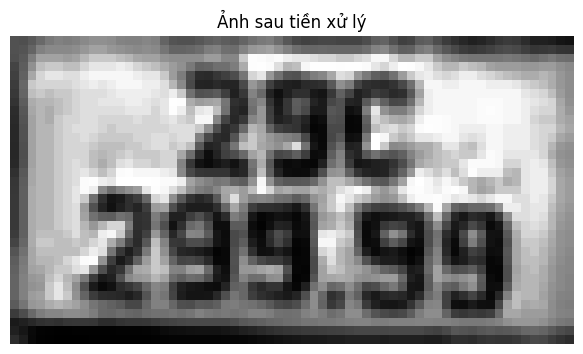

In [74]:
# 3. Preprocess Image for OCR
# Chuyển sang ảnh xám, tăng tương phản, lọc nhiễu, threshold
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (3,3), 0)
img_eq = cv2.equalizeHist(img_blur)
_, img_thresh = cv2.threshold(img_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.figure(figsize=(8,4))
plt.imshow(img_eq, cmap='gray')
plt.title('Ảnh sau tiền xử lý')
plt.axis('off')
plt.show()

In [75]:
# 4b. Apply OCR using PaddleOCRWrapper
from VehicleDetectionTracker.function.paddleocr_wrapper import PaddleOCRWrapper

# Khởi tạo PaddleOCRWrapper
ocr_wrapper = PaddleOCRWrapper(lang='en', use_angle_cls=True)

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ADMIN\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.


[2026-01-21 15:53:27] ✓ PaddleOCR: PaddlePaddle được compile cho CPU, sử dụng CPU


Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ADMIN\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ADMIN\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ADMIN\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\ADMIN\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


[2026-01-21 15:53:29] OK: PaddleOCR initialized successfully (lang=en, device=CPU)


In [80]:

# Nhận diện biển số từ ảnh đã tiền xử lý
paddle_text = ocr_wrapper.read_license_plate(img)
print('Kết quả nhận diện biển số (PaddleOCR):', paddle_text)

[2026-01-21 15:54:34] text_results: [('299.99', 0.9996330142021179), ('322', 0.4087059199810028)]
[2026-01-21 15:54:34] DEBUG: All OCR results: ['299.99']
Kết quả nhận diện biển số (PaddleOCR): unknown


In [77]:
# # 4. Apply OCR to Extract Text
# custom_config = r'--oem 3 --psm 7'
# ocr_result = pytesseract.image_to_data(img_thresh, output_type=Output.DICT, config=custom_config, lang='eng')
# text = pytesseract.image_to_string(img_thresh, config=custom_config, lang='eng')
# print('Kết quả nhận diện biển số:', text.strip())

In [78]:
# # 5. Visualize OCR Results
# img_result = img_rgb.copy()
# n_boxes = len(ocr_result['level'])
# for i in range(n_boxes):
#     (x, y, w, h) = (ocr_result['left'][i], ocr_result['top'][i], ocr_result['width'][i], ocr_result['height'][i])
#     conf = int(ocr_result['conf'][i])
#     if conf > 40 and ocr_result['text'][i].strip():
#         cv2.rectangle(img_result, (x, y), (x + w, y + h), (0,255,0), 2)
#         cv2.putText(img_result, ocr_result['text'][i], (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
# plt.figure(figsize=(8,4))
# plt.imshow(img_result)
# plt.title('Kết quả nhận diện OCR trên ảnh')
# plt.axis('off')
# plt.show()